# 6.2 - Multi-dataset benchmark analysis

This notebook analyses the benchmark parquet files produced by `scripts/benchmark.py` across multiple tabular datasets.

**Current sections**
1. Load and overview
2. Validity
3. Proximity

Distances, sparsity, and related quality metrics are always interpreted **only on valid counterfactuals**.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

REPO_ROOT = Path("..").resolve()
SRC_ROOT = REPO_ROOT / "src"
DATA_ROOT = REPO_ROOT / "data"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

RESULT_FILES = {
    "Adult": Path("../results/benchmark_adult_meeting.parquet"),
    "COMPAS": Path("../results/benchmark_compas_meeting.parquet"),
    "German Credit": Path("../results/benchmark_german_credit_meeting.parquet"),
    "HELOC": Path("../results/benchmark_heloc_meeting.parquet"),
    # "Give Me Some Credit": Path("../results/benchmark_give_me_some_credit_meeting.parquet"),
    "Lending Club": Path("../results/benchmark_lending_club_meeting.parquet"),
}

METHOD_LABELS = {
    "nn": "Nearest Neighbor",
    "dice": "DiCE",
    "gs": "Growing Spheres",
    "face": "FACE",
    "certcf": "Our method",
}

dataset_order = list(RESULT_FILES.keys())


## 1. Load and overview

In [6]:
def load_available_results(files):
    frames = []
    status_rows = []
    for dataset_name, path in files.items():
        exists = path.exists()
        status_rows.append({"dataset": dataset_name, "path": str(path), "available": exists})
        if exists:
            df_part = pd.read_parquet(path).copy()
            df_part["dataset"] = dataset_name
            frames.append(df_part)
    status_df = pd.DataFrame(status_rows)
    if not frames:
        raise RuntimeError("No benchmark parquet files were found.")
    df_all = pd.concat(frames, ignore_index=True)
    df_all["method_label"] = df_all["method"].map(METHOD_LABELS).fillna(df_all["method"])
    return df_all, status_df


df, status_df = load_available_results(RESULT_FILES)

print("Loaded datasets:", sorted(df["dataset"].unique()))
print("Methods:", sorted(df["method_label"].unique()))
print("Rows:", len(df))

Loaded datasets: ['Adult', 'COMPAS', 'German Credit', 'HELOC', 'Lending Club']
Methods: ['DiCE', 'FACE', 'Growing Spheres', 'Nearest Neighbor', 'Our method']
Rows: 1250


## 2. Validity

Validity measures whether a counterfactual is classified in the desired target class.

To compare methods more informatively than with a single percentage, we plot validity as a function of an allowed L2 distance budget. For each method, the curve shows the fraction of queries for which a valid counterfactual is found within a given distance. Failed queries are treated as having infinite distance, so the plateau of each curve coincides with the overall validity.

This plot should be read as follows:
- a higher plateau means higher overall validity
- a steeper early rise means valid counterfactuals are found with smaller changes

In [8]:
method_order = (
    df.groupby("method_label")["success"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)
palette = dict(zip(method_order, sns.color_palette("tab10", len(method_order))))

validity_table = (
    df.groupby(["method_label", "dataset"])["success"]
    .mean()
    .mul(100)
    .unstack("dataset")
    .reindex(method_order)
)

display(validity_table.style.format("{:.1f}%").background_gradient(cmap="YlGn", axis=0))


dataset,Adult,COMPAS,German Credit,HELOC,Lending Club
method_label,,,,,
Our method,100.0%,100.0%,100.0%,100.0%,100.0%
Nearest Neighbor,100.0%,100.0%,100.0%,100.0%,100.0%
DiCE,100.0%,94.0%,84.0%,100.0%,100.0%
Growing Spheres,80.0%,100.0%,62.0%,92.0%,100.0%
FACE,40.0%,94.0%,6.0%,72.0%,88.0%


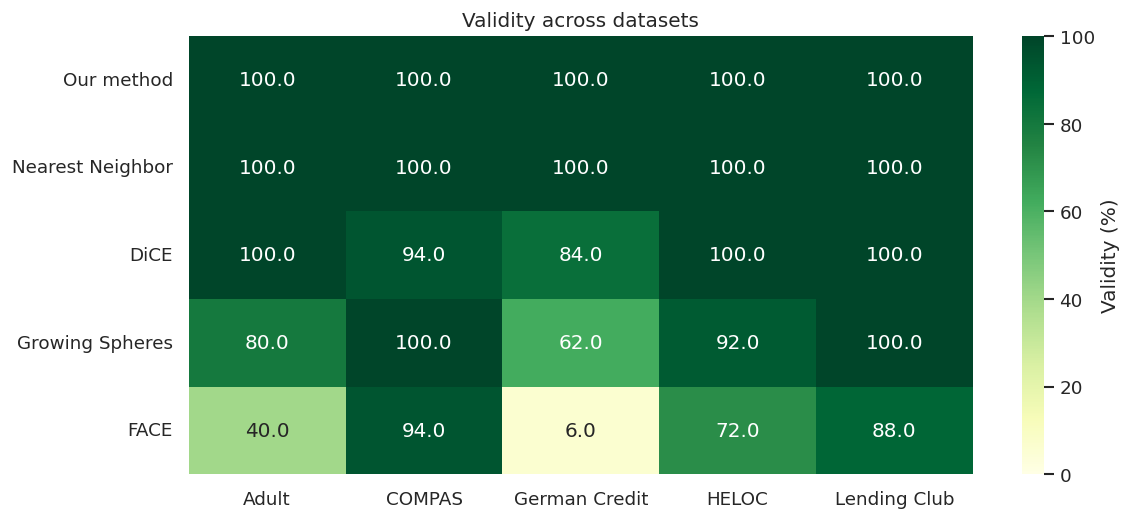

In [9]:
plt.figure(figsize=(10, 4.5))
sns.heatmap(
    validity_table,
    annot=True,
    fmt=".1f",
    cmap="YlGn",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Validity (%)"},
)
plt.title("Validity across datasets")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


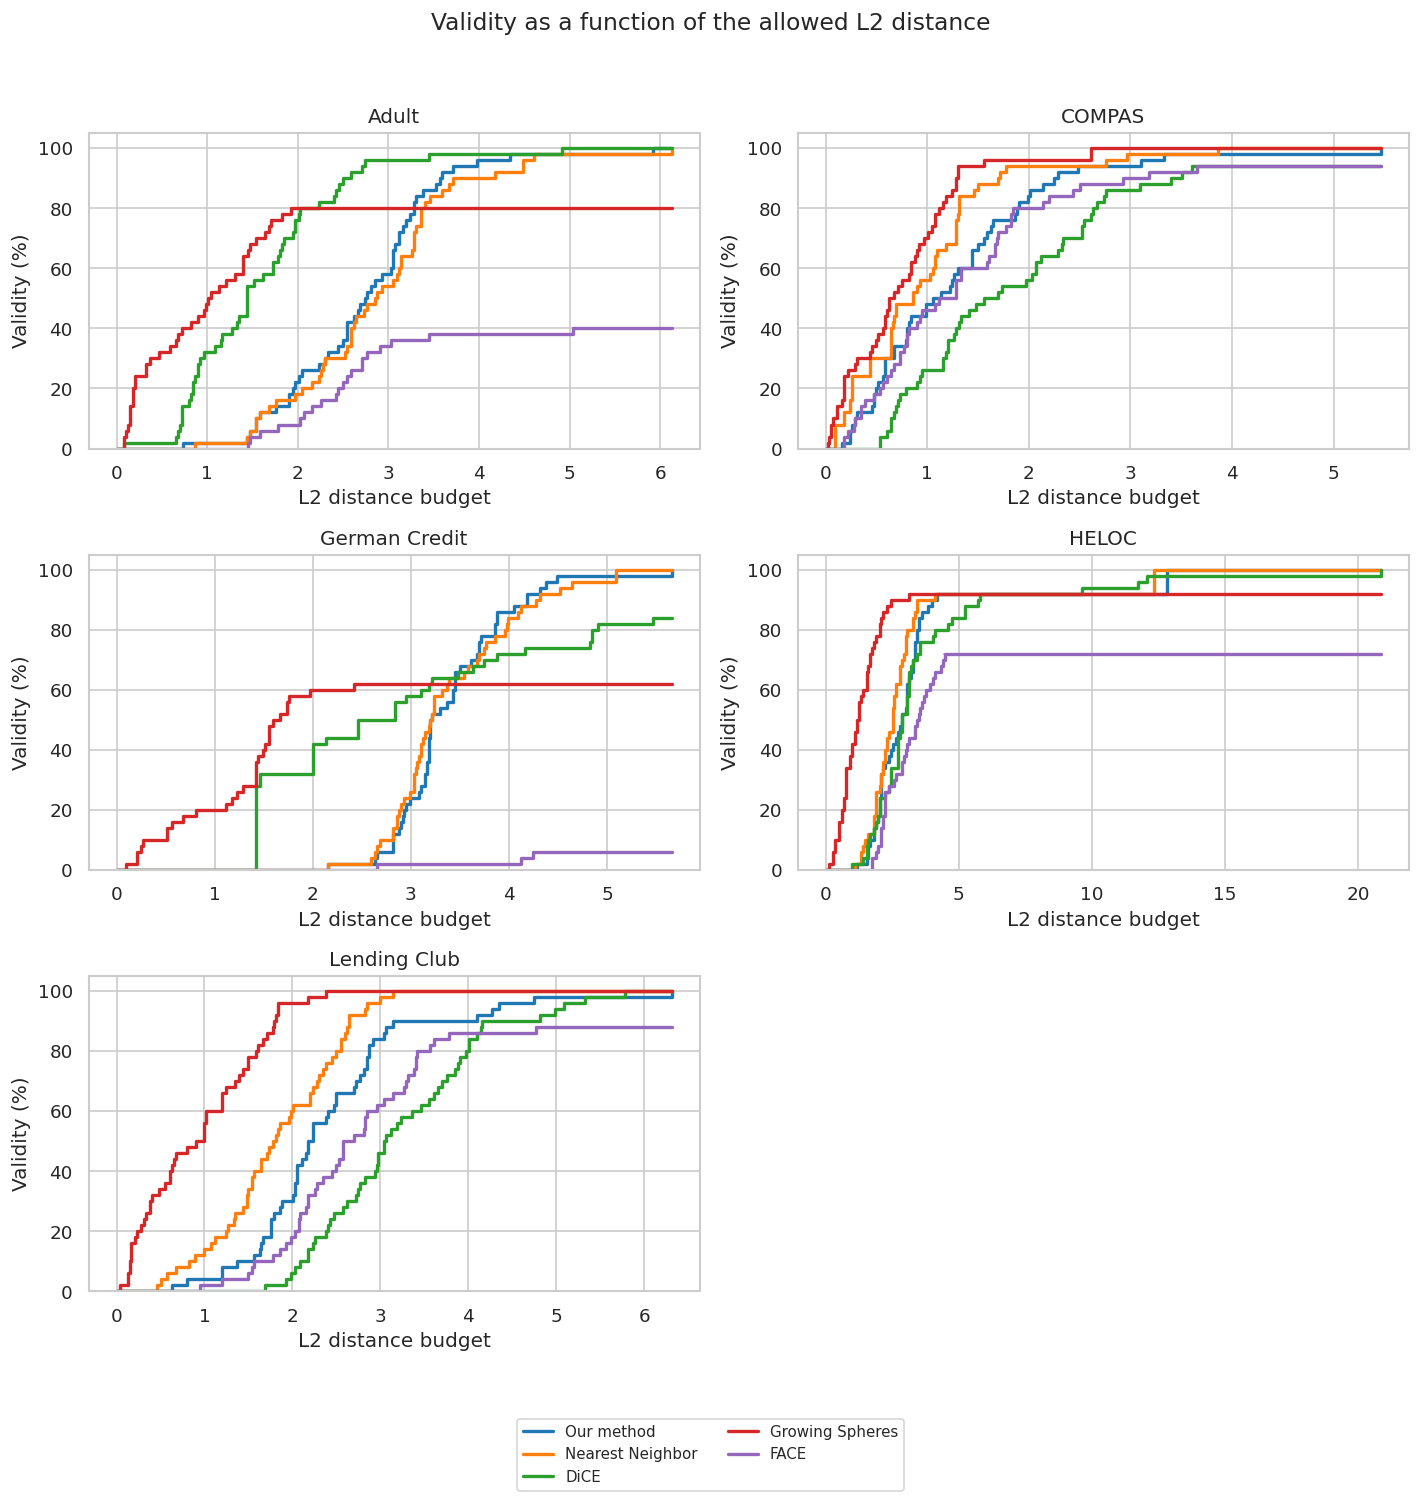

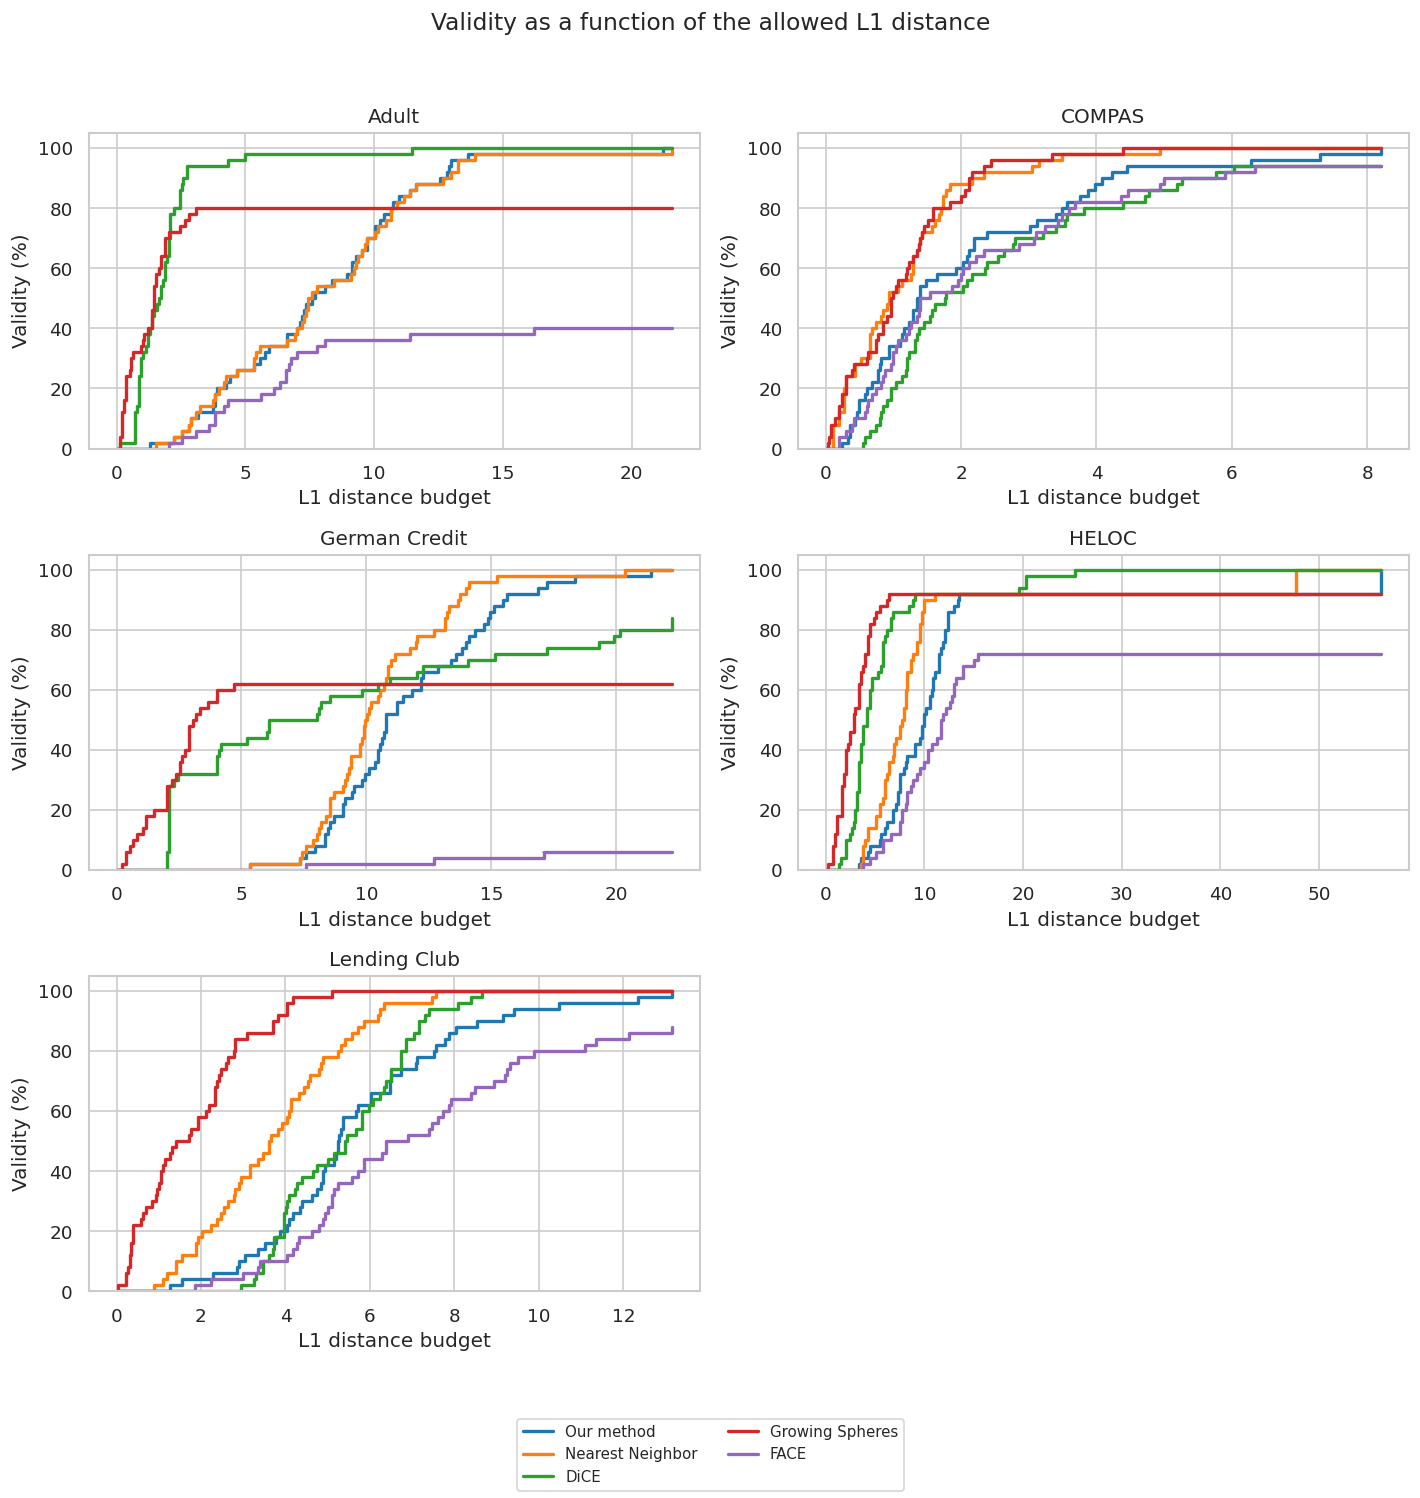

In [10]:
def validity_proximity_curve(distances, eps_grid=None, n_thresholds=300):
    distances = np.asarray(distances, dtype=float)
    finite = np.sort(distances[np.isfinite(distances)])
    max_finite = float(finite.max()) if finite.size else 0.0

    if eps_grid is None:
        eps_grid = np.linspace(0.0, max_finite, n_thresholds) if max_finite > 0 else np.array([0.0])
    else:
        eps_grid = np.asarray(eps_grid, dtype=float)

    success_curve = np.searchsorted(finite, eps_grid, side="right") / len(distances)
    plateau_pct = 100.0 * finite.size / len(distances)

    if eps_grid.size > 1 and eps_grid[-1] > 0:
        area = np.trapezoid(success_curve, eps_grid)
        auc = area / eps_grid[-1]
    else:
        auc = plateau_pct / 100.0

    return eps_grid, 100.0 * success_curve, plateau_pct, auc, max_finite


datasets_here = [d for d in dataset_order if d in df["dataset"].unique()]
n = len(datasets_here)
ncols = 2
nrows = int(np.ceil(n / ncols))

curve_rows_l2 = []
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.2 * nrows), squeeze=False)
axes = axes.ravel()

for ax, dataset_name in zip(axes, datasets_here):
    sub_ds = df[df["dataset"] == dataset_name].copy()

    finite_l2 = sub_ds.loc[sub_ds["success"], "l2_distance"].to_numpy(dtype=float)
    finite_l2 = finite_l2[np.isfinite(finite_l2)]
    max_l2 = float(finite_l2.max()) if finite_l2.size else 0.0
    eps_grid = np.linspace(0.0, max_l2, 300) if max_l2 > 0 else np.array([0.0])

    for method in method_order:
        sub_m = sub_ds[sub_ds["method_label"] == method]
        if sub_m.empty:
            continue

        distances = sub_m["l2_distance"].to_numpy(dtype=float)
        success_mask = sub_m["success"].to_numpy(dtype=bool)
        distances[~success_mask] = np.inf
        distances[~np.isfinite(distances)] = np.inf

        x, y, plateau, auc, max_finite = validity_proximity_curve(distances, eps_grid=eps_grid)

        ax.step(x, y, where="post", linewidth=2, color=palette[method], label=method)
        ax.hlines(
            plateau,
            xmin=max_finite,
            xmax=eps_grid[-1] if eps_grid.size else 0.0,
            colors=palette[method],
            linestyles="--",
            linewidth=1.2,
            alpha=0.45,
        )

        curve_rows_l2.append({
            "dataset": dataset_name,
            "method": method,
            "max_validity_pct": plateau,
            "auc_norm": auc,
        })

    ax.set_title(dataset_name)
    ax.set_xlabel("L2 distance budget")
    ax.set_ylabel("Validity (%)")
    ax.set_ylim(0, 105)

for ax in axes[n:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=9, frameon=True)
fig.suptitle("Validity as a function of the allowed L2 distance", fontsize=14)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

curve_rows_l1 = []
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.2 * nrows), squeeze=False)
axes = axes.ravel()

for ax, dataset_name in zip(axes, datasets_here):
    sub_ds = df[df["dataset"] == dataset_name].copy()

    finite_l1 = sub_ds.loc[sub_ds["success"], "l1_distance"].to_numpy(dtype=float)
    finite_l1 = finite_l1[np.isfinite(finite_l1)]
    max_l1 = float(finite_l1.max()) if finite_l1.size else 0.0
    eps_grid = np.linspace(0.0, max_l1, 300) if max_l1 > 0 else np.array([0.0])

    for method in method_order:
        sub_m = sub_ds[sub_ds["method_label"] == method]
        if sub_m.empty:
            continue

        distances = sub_m["l1_distance"].to_numpy(dtype=float)
        success_mask = sub_m["success"].to_numpy(dtype=bool)
        distances[~success_mask] = np.inf
        distances[~np.isfinite(distances)] = np.inf

        x, y, plateau, auc, max_finite = validity_proximity_curve(distances, eps_grid=eps_grid)

        ax.step(x, y, where="post", linewidth=2, color=palette[method], label=method)
        ax.hlines(
            plateau,
            xmin=max_finite,
            xmax=eps_grid[-1] if eps_grid.size else 0.0,
            colors=palette[method],
            linestyles="--",
            linewidth=1.2,
            alpha=0.45,
        )

        curve_rows_l1.append({
            "dataset": dataset_name,
            "method": method,
            "max_validity_pct": plateau,
            "auc_norm": auc,
        })

    ax.set_title(dataset_name)
    ax.set_xlabel("L1 distance budget")
    ax.set_ylabel("Validity (%)")
    ax.set_ylim(0, 105)

for ax in axes[n:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=9, frameon=True)
fig.suptitle("Validity as a function of the allowed L1 distance", fontsize=14)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


In [11]:
curve_summary_l2 = (
    pd.DataFrame(curve_rows_l2)
    .pivot(index="method", columns="dataset", values="auc_norm")
    .reindex(method_order)
)

print("Normalized AUC summary from the L2 validity-distance curves")
display(curve_summary_l2.style.format("{:.3f}").background_gradient(cmap="Blues", axis=0))

curve_summary_l1 = (
    pd.DataFrame(curve_rows_l1)
    .pivot(index="method", columns="dataset", values="auc_norm")
    .reindex(method_order)
)

print("Normalized AUC summary from the L1 validity-distance curves")
display(curve_summary_l1.style.format("{:.3f}").background_gradient(cmap="Blues", axis=0))


Normalized AUC summary from the L2 validity-distance curves


dataset,Adult,COMPAS,German Credit,HELOC,Lending Club
method,,,,,
Our method,0.557,0.768,0.400,0.835,0.619
Nearest Neighbor,0.535,0.827,0.401,0.848,0.713
DiCE,0.744,0.648,0.463,0.820,0.488
Growing Spheres,0.695,0.867,0.492,0.868,0.853
FACE,0.238,0.729,0.021,0.620,0.522


Normalized AUC summary from the L1 validity-distance curves


dataset,Adult,COMPAS,German Credit,HELOC,Lending Club
method,,,,,
Our method,0.635,0.749,0.475,0.771,0.566
Nearest Neighbor,0.634,0.860,0.528,0.816,0.718
DiCE,0.915,0.685,0.557,0.900,0.591
Growing Spheres,0.758,0.864,0.559,0.876,0.867
FACE,0.287,0.710,0.026,0.594,0.439


Validity should be interpreted before all other metrics: proximity and sparsity are only meaningful when the counterfactual is valid.

In the plots above:
- the final plateau corresponds to the total validity of the method
- curves that rise earlier indicate methods that achieve valid counterfactuals with smaller perturbations
- the normalized AUC provides a compact summary of this validity-proximity trade-off

## 3. Proximity

After checking validity, we compare proximity **only on valid counterfactuals**.

Proximity measures how far a successful counterfactual is from the original instance. We report both L1 and L2 distances:
- L1 captures the total amount of change across features
- L2 captures the overall Euclidean magnitude of the change

Lower values indicate counterfactuals that stay closer to the original point.

In [13]:
# For each dataset, keep only query_idx values where ALL methods succeeded,
# then filter df to those rows (still requiring success=True).
common_valid = []
for dataset_name in df["dataset"].unique():
    sub = df[df["dataset"] == dataset_name]
    pivot = sub.pivot_table(
        index="query_idx", columns="method_label", values="success", aggfunc="max"
    )
    all_valid_idxs = pivot.index[pivot.all(axis=1)]
    mask = (
        (df["dataset"] == dataset_name)
        & df["query_idx"].isin(all_valid_idxs)
        & df["success"]
    )
    common_valid.append(df[mask])

df_ok = pd.concat(common_valid, ignore_index=True)
print(f"Rows in df_ok (intersection-valid): {len(df_ok)}")
print(df_ok.groupby(["dataset", "method_label"]).size().unstack(fill_value=0))

Rows in df_ok (intersection-valid): 715
method_label  DiCE  FACE  Growing Spheres  Nearest Neighbor  Our method
dataset                                                                
Adult           19    19               19                19          19
COMPAS          44    44               44                44          44
HELOC           36    36               36                36          36
Lending Club    44    44               44                44          44


In [14]:
valid_counts = (
    df_ok.groupby(["dataset", "method_label"])
    .size()
    .unstack(fill_value=0)
)

display(valid_counts)

method_label,DiCE,FACE,Growing Spheres,Nearest Neighbor,Our method
dataset,,,,,
Adult,19,19,19,19,19
COMPAS,44,44,44,44,44
HELOC,36,36,36,36,36
Lending Club,44,44,44,44,44


In [16]:
l1_table = (
    df_ok.groupby(["method_label", "dataset"])["l1_distance"]
    .mean()
    .unstack("dataset")
    .reindex(method_order)
)

l2_table = (
    df_ok.groupby(["method_label", "dataset"])["l2_distance"]
    .mean()
    .unstack("dataset")
    .reindex(method_order)
)

print("Mean L1 distance on valid counterfactuals")
display(l1_table.style.format("{:.3f}").background_gradient(cmap="Blues_r", axis=0))

print("Mean L2 distance on valid counterfactuals")
display(l2_table.style.format("{:.3f}").background_gradient(cmap="Blues_r", axis=0))


Mean L1 distance on valid counterfactuals


dataset,Adult,COMPAS,HELOC,Lending Club
method_label,,,,
Our method,4.316,1.822,8.623,5.270
Nearest Neighbor,4.246,0.969,6.830,3.543
DiCE,1.350,2.237,4.143,5.441
Growing Spheres,0.709,1.071,2.679,1.731
FACE,5.561,2.016,9.840,6.592


Mean L2 distance on valid counterfactuals


dataset,Adult,COMPAS,HELOC,Lending Club
method_label,,,,
Our method,1.927,1.118,2.480,2.160
Nearest Neighbor,2.019,0.837,2.302,1.771
DiCE,1.085,1.671,2.817,3.235
Growing Spheres,0.425,0.684,1.134,0.928
FACE,2.349,1.216,2.911,2.570


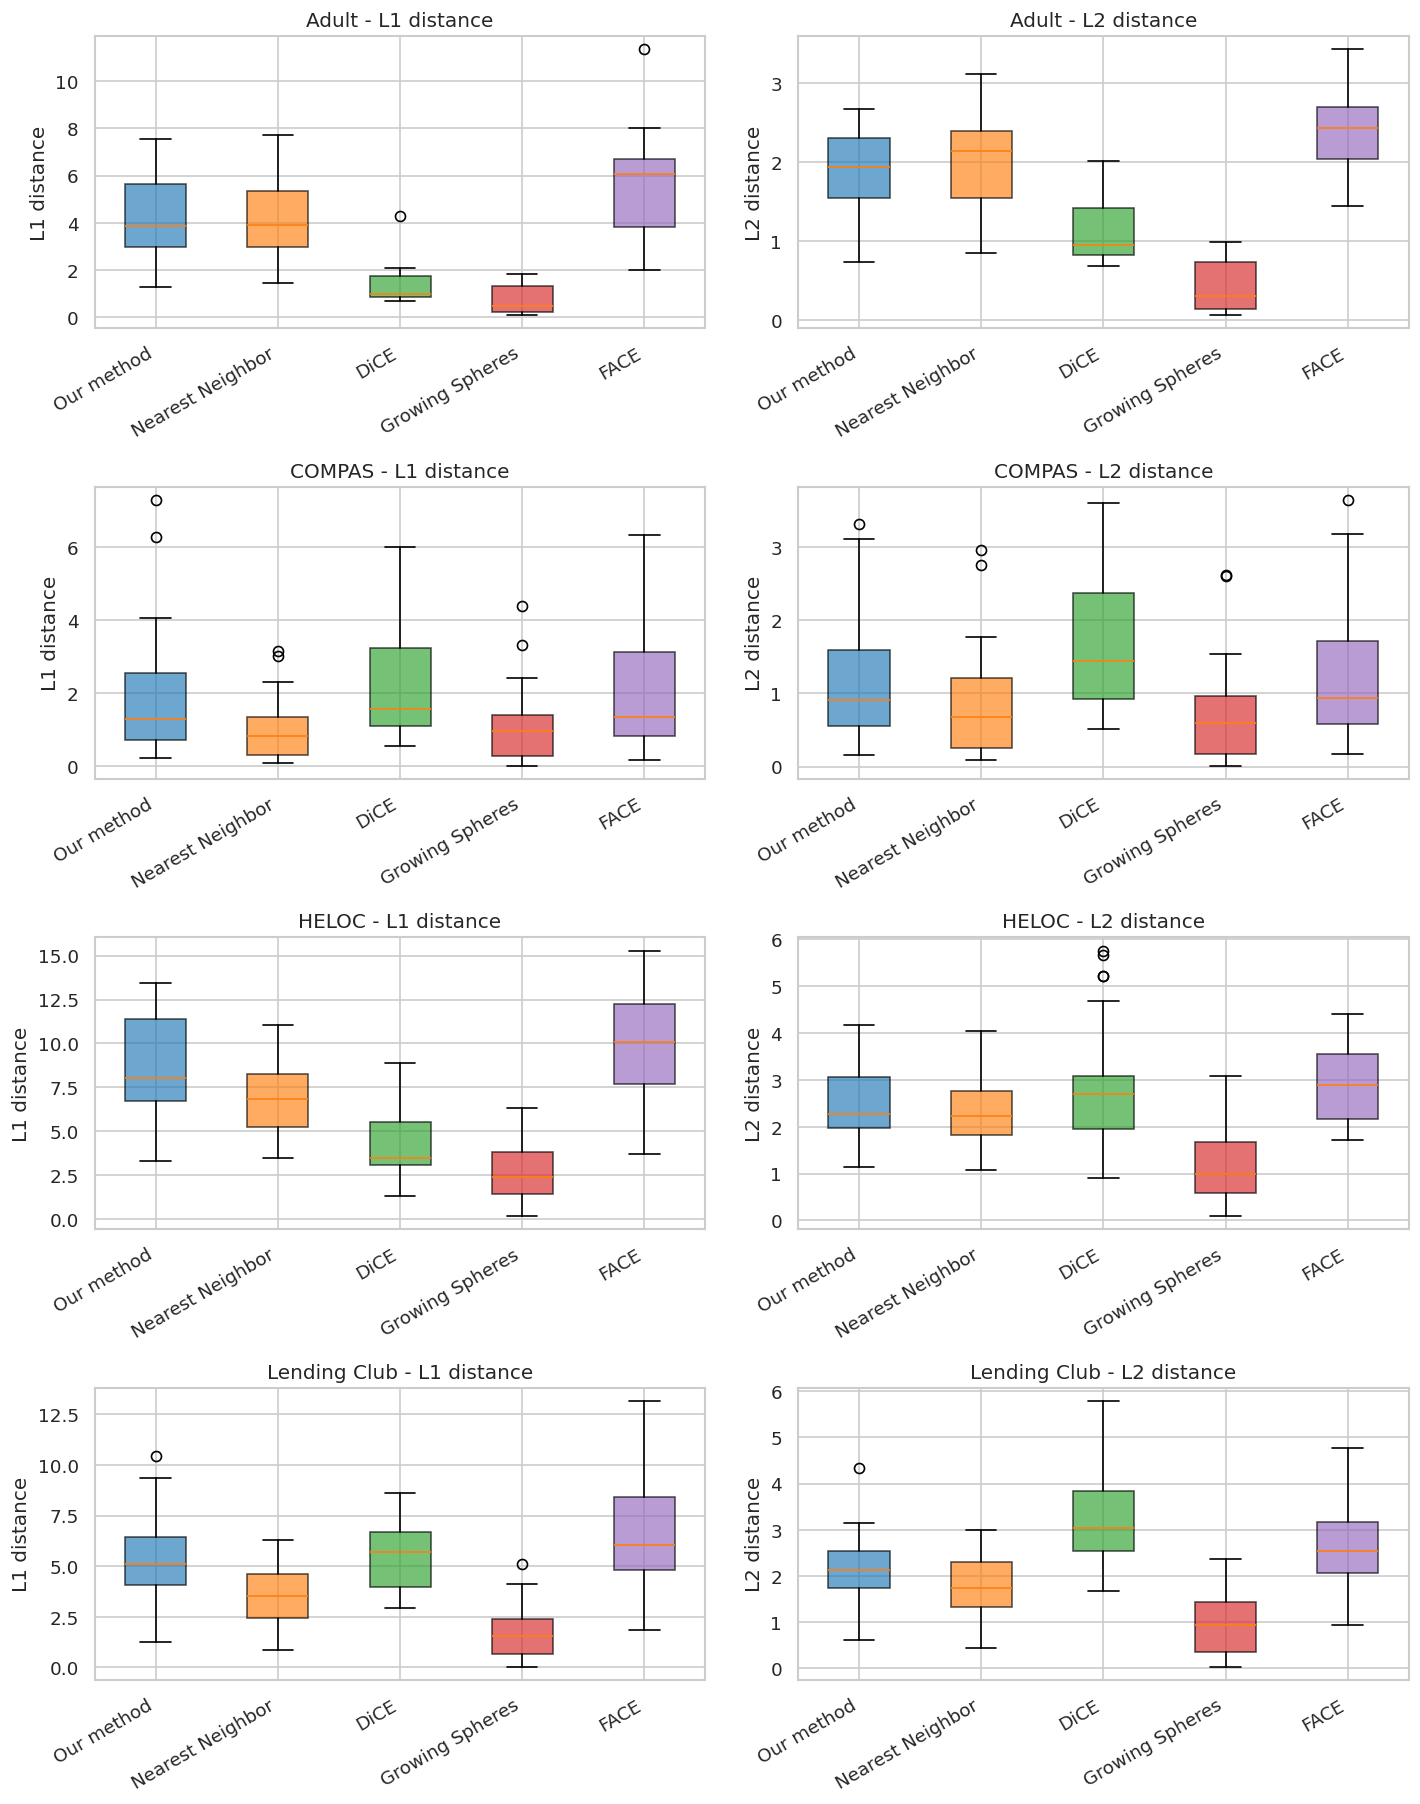

In [17]:
datasets_here = [d for d in dataset_order if d in df_ok["dataset"].unique()]
n = len(datasets_here)
fig, axes = plt.subplots(n, 2, figsize=(12, 3.8 * n), squeeze=False)

for i, dataset_name in enumerate(datasets_here):
    sub = df_ok[df_ok["dataset"] == dataset_name]
    methods_here = [m for m in method_order if m in sub["method_label"].unique()]
    colors_here = [palette[m] for m in methods_here]

    data_l1 = [sub[sub["method_label"] == m]["l1_distance"].dropna().values for m in methods_here]
    bp1 = axes[i, 0].boxplot(data_l1, vert=True, patch_artist=True, tick_labels=methods_here)
    for patch, color in zip(bp1["boxes"], colors_here):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    axes[i, 0].set_title(f"{dataset_name} - L1 distance")
    axes[i, 0].set_ylabel("L1 distance")
    axes[i, 0].set_xticklabels(methods_here, rotation=30, ha="right")

    data_l2 = [sub[sub["method_label"] == m]["l2_distance"].dropna().values for m in methods_here]
    bp2 = axes[i, 1].boxplot(data_l2, vert=True, patch_artist=True, tick_labels=methods_here)
    for patch, color in zip(bp2["boxes"], colors_here):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    axes[i, 1].set_title(f"{dataset_name} - L2 distance")
    axes[i, 1].set_ylabel("L2 distance")
    axes[i, 1].set_xticklabels(methods_here, rotation=30, ha="right")

plt.tight_layout()
plt.show()


In [18]:
prox_summary = (
    df_ok.groupby("method_label")
    .agg(
        mean_l1=("l1_distance", "mean"),
        std_l1=("l1_distance", "std"),
        mean_l2=("l2_distance", "mean"),
        std_l2=("l2_distance", "std"),
        n_valid=("success", "size"),
    )
    .reindex(method_order)
)

display(
    prox_summary.style.format({
        "mean_l1": "{:.3f}",
        "std_l1": "{:.3f}",
        "mean_l2": "{:.3f}",
        "std_l2": "{:.3f}",
        "n_valid": "{:d}",
    })
    .background_gradient(cmap="Blues_r", axis=0, subset=["mean_l1", "std_l1", "mean_l2", "std_l2"])
    .background_gradient(cmap="Greens", axis=0, subset=["n_valid"])
)


,mean_l1,std_l1,mean_l2,std_l2,n_valid
method_label,,,,,
Our method,4.927,3.310,1.889,0.883,143
Nearest Neighbor,3.672,2.670,1.650,0.869,143
DiCE,3.585,2.207,2.363,1.252,143
Growing Spheres,1.631,1.394,0.838,0.652,143
FACE,5.865,3.826,2.210,1.036,143


These proximity values are computed only on valid counterfactuals.

This is important: a method should not be rewarded for staying close to the original point if it fails to reach the target class. Proximity therefore complements validity rather than replacing it.

## 4. Sparsity

We now compare sparsity **only on valid counterfactuals**.

Sparsity measures the fraction of features that change between the original instance and the counterfactual. Lower values indicate simpler explanations, since fewer input dimensions need to be modified to reach the target class.

In [57]:
sparsity_table = (
    df_ok.groupby(["method_label", "dataset"])["l0_sparsity"]
    .mean()
    .mul(100)
    .unstack("dataset")
    .reindex(method_order)
)

display(sparsity_table.style.format("{:.1f}%").background_gradient(cmap="Blues_r", axis=0))


dataset,Adult,COMPAS,HELOC,Lending Club
method_label,,,,
Our method,5.8%,24.0%,74.3%,31.5%
Nearest Neighbor,5.3%,14.4%,62.9%,26.4%
DiCE,2.7%,24.4%,19.7%,81.2%
Growing Spheres,3.2%,21.1%,30.2%,20.0%
FACE,6.0%,25.3%,73.4%,33.7%


/tmp/ipykernel_16255/2788354467.py:15: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, tick_labels=methods_here)
/tmp/ipykernel_16255/2788354467.py:15: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, tick_labels=methods_here)
/tmp/ipykernel_16255/2788354467.py:15: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, tick_labels=methods_here)
/tmp/ipykernel_16255/2788354467.py:15: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, tick_labels=methods_here)


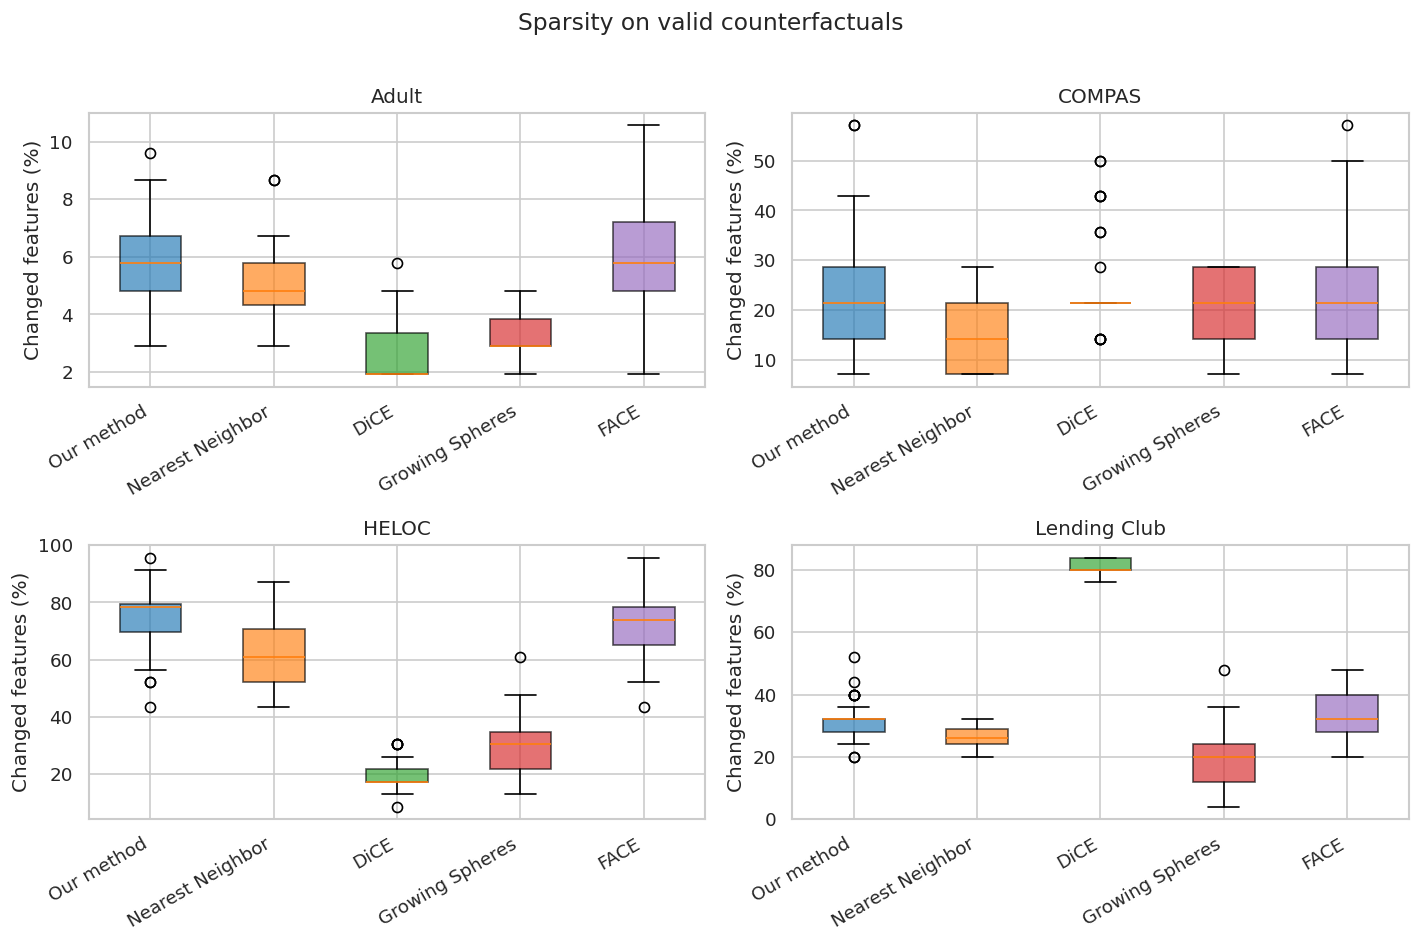

In [58]:
datasets_here = [d for d in dataset_order if d in df_ok["dataset"].unique()]
n = len(datasets_here)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.0 * nrows), squeeze=False)
axes = axes.ravel()

for ax, dataset_name in zip(axes, datasets_here):
    sub = df_ok[df_ok["dataset"] == dataset_name]
    methods_here = [m for m in method_order if m in sub["method_label"].unique()]
    colors_here = [palette[m] for m in methods_here]
    data = [100.0 * sub[sub["method_label"] == m]["l0_sparsity"].dropna().values for m in methods_here]

    bp = ax.boxplot(data, vert=True, patch_artist=True, tick_labels=methods_here)
    for patch, color in zip(bp["boxes"], colors_here):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_title(dataset_name)
    ax.set_ylabel("Changed features (%)")
    ax.set_xticklabels(methods_here, rotation=30, ha="right")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("Sparsity on valid counterfactuals", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [59]:
sparsity_summary = (
    df_ok.groupby("method_label")
    .agg(
        mean_sparsity=("l0_sparsity", lambda s: 100.0 * s.mean()),
        std_sparsity=("l0_sparsity", lambda s: 100.0 * s.std()),
        n_valid=("success", "size"),
    )
    .reindex(method_order)
)

display(
    sparsity_summary.style.format({
        "mean_sparsity": "{:.1f}%",
        "std_sparsity": "{:.1f}%",
        "n_valid": "{:d}",
    })
    .background_gradient(cmap="Blues_r", axis=0, subset=["mean_sparsity", "std_sparsity"])
    .background_gradient(cmap="Greens", axis=0, subset=["n_valid"])
)


,mean_sparsity,std_sparsity,n_valid
method_label,,,
Our method,36.6%,25.1%,143
Nearest Neighbor,29.1%,22.2%,143
DiCE,37.8%,30.3%,143
Growing Spheres,20.7%,11.5%,143
FACE,37.5%,24.5%,143


Sparsity is again evaluated only on valid counterfactuals.

A sparse counterfactual is often easier to interpret, because it suggests a smaller set of changes. However, sparsity should always be read together with validity and proximity: extremely sparse counterfactuals are only useful if they are both valid and reasonably close to the original point.

## 5. Plausibility

Plausibility is not stored in the benchmark parquet files, so we compute it post hoc from the valid counterfactuals and the training data of each dataset.

We use three complementary metrics:
- **k-NN distance**: mean distance to the nearest training points; lower is better
- **LOF score**: Local Outlier Factor score; higher means more in-distribution
- **KDE log-density**: kernel density estimate score; higher means denser and therefore more plausible regions

As in `6.1`, we compare each method against a reference sample drawn directly from the training set.

In [60]:
from counterfactuals.datasets.loaders import (
    AdultDataset,
    CompasDataset,
    GermanCreditDataset,
    GiveMeSomeCreditDataset,
    HELOCDataset,
    LendingClubDataset,
)
from sklearn.neighbors import KernelDensity, LocalOutlierFactor, NearestNeighbors

DATASET_LOADERS = {
    "Adult": lambda: AdultDataset(data_dir=str(DATA_ROOT), seed=42),
    "COMPAS": lambda: CompasDataset(data_dir=str(DATA_ROOT), seed=42),
    "German Credit": lambda: GermanCreditDataset(data_dir=str(DATA_ROOT), seed=42),
    "HELOC": lambda: HELOCDataset(data_dir=str(DATA_ROOT), seed=42),
    "Give Me Some Credit": lambda: GiveMeSomeCreditDataset(data_dir=str(DATA_ROOT), seed=42),
    "Lending Club": lambda: LendingClubDataset(data_dir=str(DATA_ROOT), seed=42),
}

train_cache = {}
for dataset_name in datasets_here:
    ds = DATASET_LOADERS[dataset_name]()
    ds.load()
    x_train_ds, y_train_ds = ds.get_train()
    train_cache[dataset_name] = {"x_train": x_train_ds, "y_train": y_train_ds}
    print(dataset_name, x_train_ds.shape)


Adult (36178, 104)
COMPAS (4938, 14)
HELOC (8369, 23)
Lending Club (30823, 25)


In [61]:
rng_plaus = np.random.default_rng(42)
plaus_rows = []
ref_rows = []

for dataset_name in datasets_here:
    x_train_ds = np.asarray(train_cache[dataset_name]["x_train"], dtype=np.float32)

    fit_size = min(5000, len(x_train_ds))
    fit_idx = rng_plaus.choice(len(x_train_ds), size=fit_size, replace=False)
    x_fit = x_train_ds[fit_idx]

    ref_size = min(500, len(x_fit))
    ref_idx = rng_plaus.choice(len(x_fit), size=ref_size, replace=False)
    x_ref = x_fit[ref_idx]

    nn_model = NearestNeighbors(n_neighbors=min(5, len(x_fit)))
    nn_model.fit(x_fit)

    lof_model = LocalOutlierFactor(n_neighbors=min(20, max(2, len(x_fit) - 1)), novelty=True)
    lof_model.fit(x_fit)

    kde_model = KernelDensity(kernel="gaussian", bandwidth=1.0)
    kde_model.fit(x_fit)

    ref_knn = nn_model.kneighbors(x_ref, return_distance=True)[0].mean(axis=1)
    ref_lof = lof_model.score_samples(x_ref)
    ref_kde = kde_model.score_samples(x_ref)

    ref_rows.extend(
        [{"dataset": dataset_name, "metric": "knn_distance", "value": float(v), "label": "[train ref]"} for v in ref_knn]
    )
    ref_rows.extend(
        [{"dataset": dataset_name, "metric": "lof_score", "value": float(v), "label": "[train ref]"} for v in ref_lof]
    )
    ref_rows.extend(
        [{"dataset": dataset_name, "metric": "kde_log_density", "value": float(v), "label": "[train ref]"} for v in ref_kde]
    )

    sub_ds = df_ok[df_ok["dataset"] == dataset_name]
    methods_here = [m for m in method_order if m in sub_ds["method_label"].unique()]

    for method in methods_here:
        sub_m = sub_ds[sub_ds["method_label"] == method]
        cols_here = sorted(
            [c for c in sub_m.columns if c.startswith("x_cf_") and not sub_m[c].isna().all()],
            key=lambda c: int(c.split("_")[-1]),
        )
        x_cf = sub_m[cols_here].to_numpy(dtype=np.float32)
        x_cf = x_cf[~np.isnan(x_cf).any(axis=1)]
        if len(x_cf) == 0:
            continue

        knn_dist = nn_model.kneighbors(x_cf, return_distance=True)[0].mean(axis=1)
        lof_score = lof_model.score_samples(x_cf)
        kde_log_density = kde_model.score_samples(x_cf)

        for v in knn_dist:
            plaus_rows.append({"dataset": dataset_name, "method": method, "metric": "knn_distance", "value": float(v)})
        for v in lof_score:
            plaus_rows.append({"dataset": dataset_name, "method": method, "metric": "lof_score", "value": float(v)})
        for v in kde_log_density:
            plaus_rows.append({"dataset": dataset_name, "method": method, "metric": "kde_log_density", "value": float(v)})

plaus_df = pd.DataFrame(plaus_rows)
ref_df = pd.DataFrame(ref_rows)
print("plausibility rows:", len(plaus_df))
print("reference rows:", len(ref_df))


plausibility rows: 2145
reference rows: 6000


In [62]:
plaus_summary = (
    plaus_df.groupby(["metric", "method", "dataset"])["value"]
    .mean()
    .reset_index()
)

metric_direction = {
    "knn_distance":      "lower is better",
    "lof_score":         "lower is better",
    "kde_log_density":   "higher is better",
}

for metric_name in ["knn_distance", "lof_score", "kde_log_density"]:
    print(f"{metric_name}  ({metric_direction[metric_name]})")
    table = (
        plaus_summary[plaus_summary["metric"] == metric_name]
        .pivot(index="method", columns="dataset", values="value")
        .reindex(method_order)
    )
    cmap = "Blues_r" if metric_name == "knn_distance" else "Blues"
    display(table.style.format("{:.3f}").background_gradient(cmap=cmap, axis=0))

knn_distance  (lower is better)


dataset,Adult,COMPAS,HELOC,Lending Club
method,,,,
Our method,0.796,0.103,1.248,0.897
Nearest Neighbor,0.701,0.173,1.389,1.164
DiCE,1.602,0.860,2.701,2.576
Growing Spheres,1.293,0.373,2.032,1.405
FACE,0.766,0.059,1.147,0.961


lof_score  (lower is better)


dataset,Adult,COMPAS,HELOC,Lending Club
method,,,,
Our method,-1.015,-1.049,-1.003,-1.015
Nearest Neighbor,-1.008,-1935997.850,-1.043,-1.090
DiCE,-1.302,-3.070,-1.460,-1.639
Growing Spheres,-1.231,-78979471.949,-1.153,-1.157
FACE,-1.009,-1.034,-0.992,-1.041


kde_log_density  (higher is better)


dataset,Adult,COMPAS,HELOC,Lending Club
method,,,,
Our method,-99.531,-14.710,-26.039,-27.175
Nearest Neighbor,-99.456,-14.932,-26.656,-27.691
DiCE,-100.749,-15.728,-29.512,-30.907
Growing Spheres,-100.351,-14.988,-27.692,-27.982
FACE,-99.583,-14.564,-25.595,-27.125


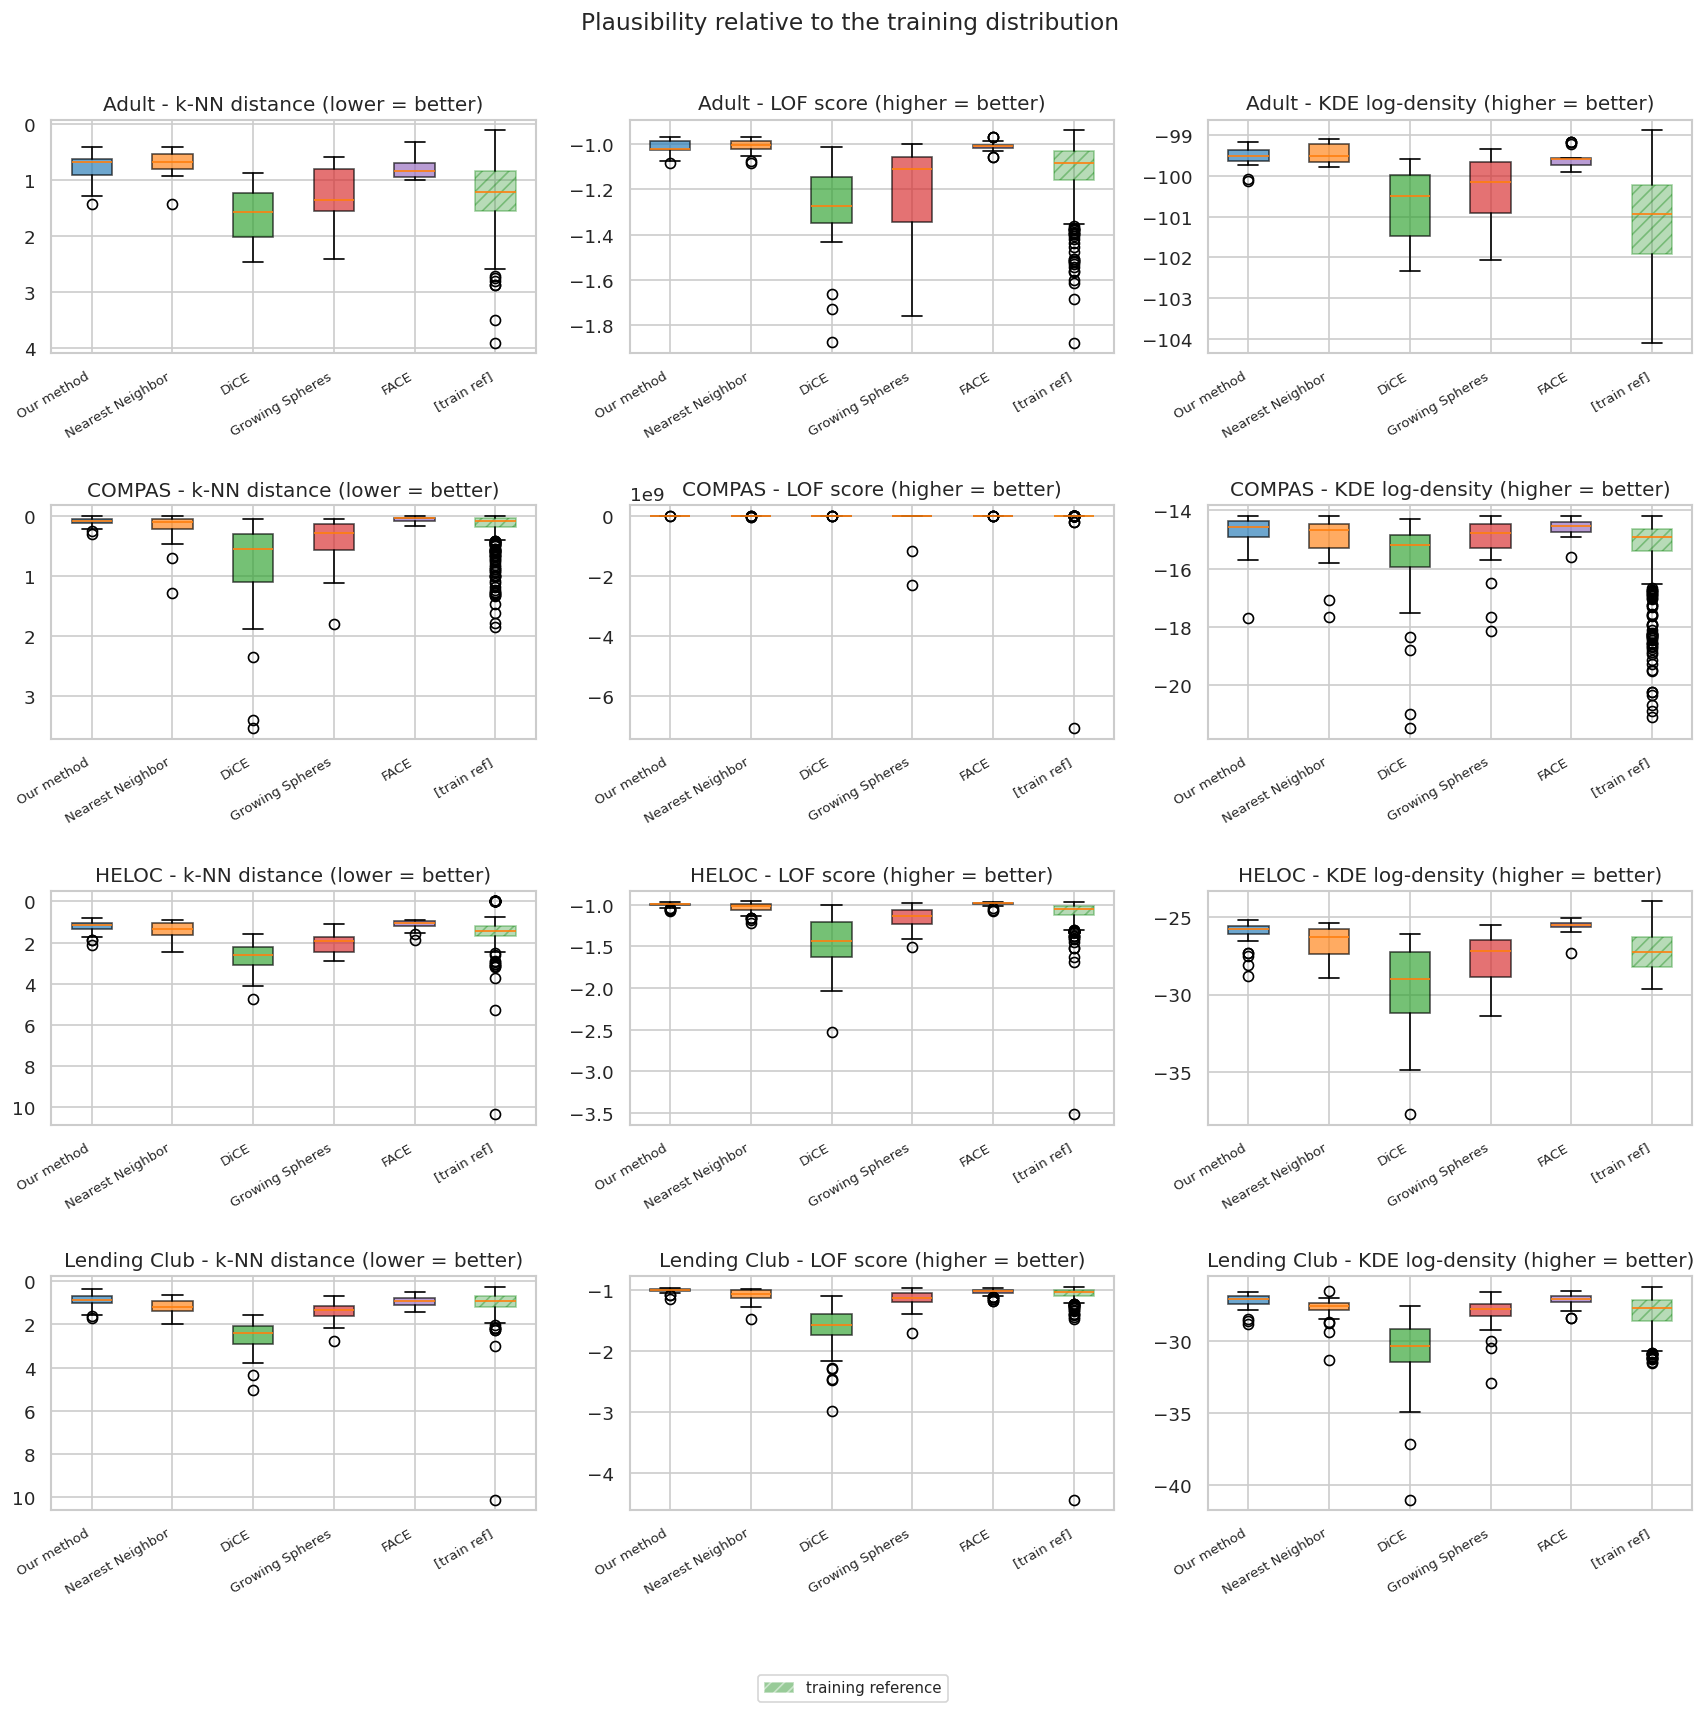

In [63]:
metric_info = [
    ("knn_distance", "k-NN distance (lower = better)", True),
    ("lof_score", "LOF score (higher = better)", False),
    ("kde_log_density", "KDE log-density (higher = better)", False),
]

from matplotlib.patches import Patch

nrows = len(datasets_here)
ncols = len(metric_info)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.6 * nrows), squeeze=False)

for i, dataset_name in enumerate(datasets_here):
    methods_here = [m for m in method_order if m in plaus_df.loc[plaus_df["dataset"] == dataset_name, "method"].unique()]
    for j, (metric_name, title, invert) in enumerate(metric_info):
        ax = axes[i, j]
        sub_metric = plaus_df[(plaus_df["dataset"] == dataset_name) & (plaus_df["metric"] == metric_name)]
        ref_metric = ref_df[(ref_df["dataset"] == dataset_name) & (ref_df["metric"] == metric_name)]

        data_by_method = [sub_metric[sub_metric["method"] == m]["value"].dropna().values for m in methods_here]
        labels = methods_here + ["[train ref]"]
        data_all = data_by_method + [ref_metric["value"].dropna().values]

        bp = ax.boxplot(data_all, orientation="vertical", patch_artist=True, tick_labels=labels)
        for k, patch in enumerate(bp["boxes"]):
            if k < len(methods_here):
                patch.set_facecolor(palette[methods_here[k]])
                patch.set_alpha(0.65)
            else:
                patch.set_facecolor((0.2, 0.6, 0.2))
                patch.set_alpha(0.35)
                patch.set_hatch("///")
                patch.set_edgecolor("green")

        if invert:
            ax.invert_yaxis()
        ax.set_title(f"{dataset_name} - {title}")
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)

handles = [Patch(facecolor=(0.2, 0.6, 0.2), hatch='///', alpha=0.5, label='training reference')]
fig.legend(handles=handles, loc="lower center", ncol=1, fontsize=9, frameon=True)
fig.suptitle("Plausibility relative to the training distribution", fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()


These plausibility metrics are computed only on valid counterfactuals.

The training-reference boxes provide a useful anchor: methods whose distributions are closer to the training reference can be interpreted as producing more realistic counterfactuals. As usual, this section should be read together with validity, proximity, and sparsity rather than in isolation.

## 6. Joint validity-closeness score

To summarize validity and proximity in a single quantity, we define a per-query utility that decreases linearly with distance and is zero for failed counterfactuals.

For a fixed L2 budget $B$, the per-query score is

$$u_B(d) = \max\left(1 - \frac{d}{B}, 0\right),$$

where failed counterfactuals are treated as having infinite distance and therefore receive score 0.

Averaging this utility across queries gives the **Validity-Closeness Score (VCS)**. Higher values indicate methods that are both more reliable and closer to the original input.

In [71]:
def validity_closeness_score(distances, budget):
    distances = np.asarray(distances, dtype=float)
    distances = np.where(np.isfinite(distances), distances, np.inf)
    return float(np.mean(np.maximum(1.0 - distances / budget, 0.0)))


vcs_rows = []
budget_rows = []

for dataset_name in datasets_here:
    sub_ds = df[df["dataset"] == dataset_name].copy()
    finite_success = sub_ds.loc[sub_ds["success"], "l2_distance"].to_numpy(dtype=float)
    finite_success = finite_success[np.isfinite(finite_success)]
    if finite_success.size == 0:
        continue

    budget = float(np.quantile(finite_success, 0.95))
    budget_rows.append({"dataset": dataset_name, "l2_budget": budget})

    for method in method_order:
        sub_m = sub_ds[sub_ds["method_label"] == method]
        if sub_m.empty:
            continue

        distances = sub_m["l2_distance"].to_numpy(dtype=float)
        success_mask = sub_m["success"].to_numpy(dtype=bool)
        distances[~success_mask] = np.inf
        distances[~np.isfinite(distances)] = np.inf

        score = validity_closeness_score(distances, budget)
        vcs_rows.append({
            "dataset": dataset_name,
            "method": method,
            "vcs": score,
            "budget": budget,
        })

vcs_df = pd.DataFrame(vcs_rows)
budget_df = pd.DataFrame(budget_rows)
display(budget_df)


,dataset,l2_budget
0,Adult,3.701114
1,COMPAS,2.753264
2,German Credit,4.536952
3,HELOC,7.473193
4,Lending Club,4.093589


In [72]:
vcs_table = (
    vcs_df.pivot(index="method", columns="dataset", values="vcs")
    .reindex(method_order)
)

display(vcs_table.style.format("{:.3f}").background_gradient(cmap="YlGn", axis=0))


dataset,Adult,COMPAS,German Credit,HELOC,Lending Club
method,,,,,
Our method,0.284,0.565,0.256,0.595,0.429
Nearest Neighbor,0.259,0.667,0.259,0.628,0.557
DiCE,0.584,0.380,0.379,0.561,0.238
Growing Spheres,0.626,0.736,0.460,0.777,0.774
FACE,0.139,0.532,0.012,0.440,0.331


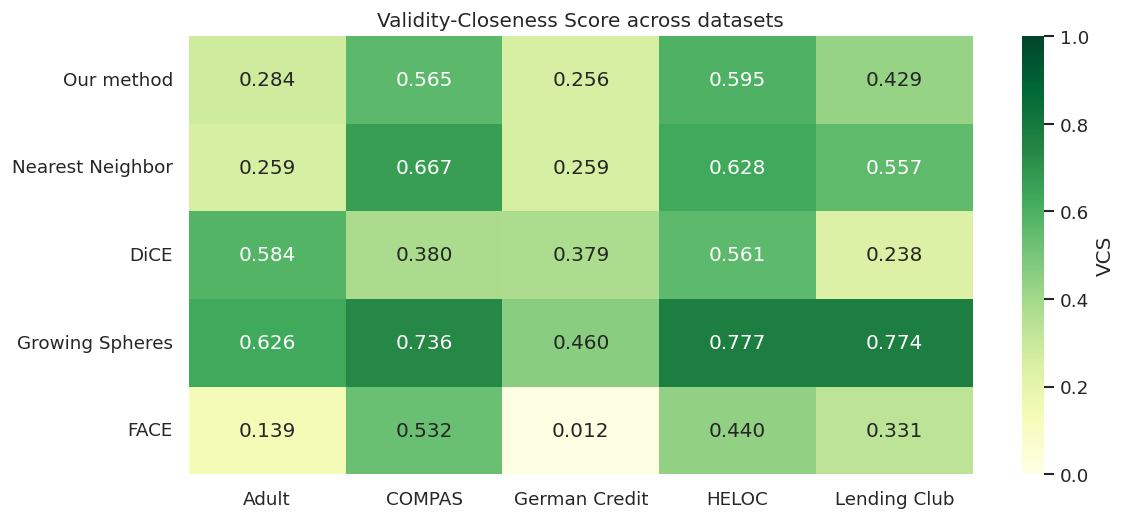

In [73]:
plt.figure(figsize=(10, 4.5))
sns.heatmap(
    vcs_table,
    annot=True,
    fmt=".3f",
    cmap="YlGn",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "VCS"},
)
plt.title("Validity-Closeness Score across datasets")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [74]:
vcs_summary = (
    vcs_df.groupby("method")
    .agg(
        mean_vcs=("vcs", "mean"),
        std_vcs=("vcs", "std"),
        n_datasets=("dataset", "size"),
    )
    .reindex(method_order)
)

display(
    vcs_summary.style.format({
        "mean_vcs": "{:.3f}",
        "std_vcs": "{:.3f}",
        "n_datasets": "{:d}",
    })
)


,mean_vcs,std_vcs,n_datasets
method,,,
Our method,0.426,0.156,5
Nearest Neighbor,0.474,0.200,5
DiCE,0.428,0.144,5
Growing Spheres,0.674,0.135,5
FACE,0.290,0.214,5


The Validity-Closeness Score should be interpreted as a joint utility measure.

A high score requires both high validity and small distances: invalid counterfactuals contribute zero, while successful but far counterfactuals contribute only a small amount. In this sense, VCS summarizes the same trade-off shown by the validity-proximity curves into a single number.

## 7. Runtime

We report runtime separately for the offline and online phases.

- `build_time_s` is the one-time setup cost of each method on a dataset
- `total_query_time_s` is the total time spent generating counterfactuals for the benchmark queries
- `mean_query_time_s` is the average per-query latency


In [75]:
build_time_table = (
    df.groupby(["method_label", "dataset"])["build_time_s"]
    .first()
    .unstack("dataset")
    .reindex(method_order)
)

total_query_time_table = (
    df.groupby(["method_label", "dataset"])["runtime_s"]
    .sum()
    .unstack("dataset")
    .reindex(method_order)
)

mean_query_time_table = (
    df.groupby(["method_label", "dataset"])["runtime_s"]
    .mean()
    .unstack("dataset")
    .reindex(method_order)
)

print("Build time (s)")
display(build_time_table.style.format("{:.3f}").background_gradient(cmap="Oranges_r", axis=0))

print("Total query phase time (s)")
display(total_query_time_table.style.format("{:.3f}").background_gradient(cmap="Greens_r", axis=0))

print("Mean query time (s)")
display(mean_query_time_table.style.format("{:.4f}").background_gradient(cmap="Greens_r", axis=0))


Build time (s)


dataset,Adult,COMPAS,German Credit,HELOC,Lending Club
method_label,,,,,
Our method,8.781,6.002,5.641,5.553,10.434
Nearest Neighbor,3.954,0.001,0.000,0.000,0.001
DiCE,0.009,0.001,0.001,0.008,0.022
Growing Spheres,0.005,0.000,0.000,0.000,0.002
FACE,5.077,3.856,0.115,0.598,4.017


Total query phase time (s)


dataset,Adult,COMPAS,German Credit,HELOC,Lending Club
method_label,,,,,
Our method,32.393,1.830,3.844,0.793,49.042
Nearest Neighbor,0.002,0.006,0.003,0.010,0.034
DiCE,240.756,119.918,440.053,27.020,35.840
Growing Spheres,1.098,0.137,0.847,0.201,0.203
FACE,0.137,0.938,0.024,0.098,0.127


Mean query time (s)


dataset,Adult,COMPAS,German Credit,HELOC,Lending Club
method_label,,,,,
Our method,0.6479,0.0366,0.0769,0.0159,0.9808
Nearest Neighbor,0.0000,0.0001,0.0001,0.0002,0.0007
DiCE,4.8151,2.3984,8.8011,0.5404,0.7168
Growing Spheres,0.0220,0.0027,0.0169,0.0040,0.0041
FACE,0.0027,0.0188,0.0005,0.0020,0.0025


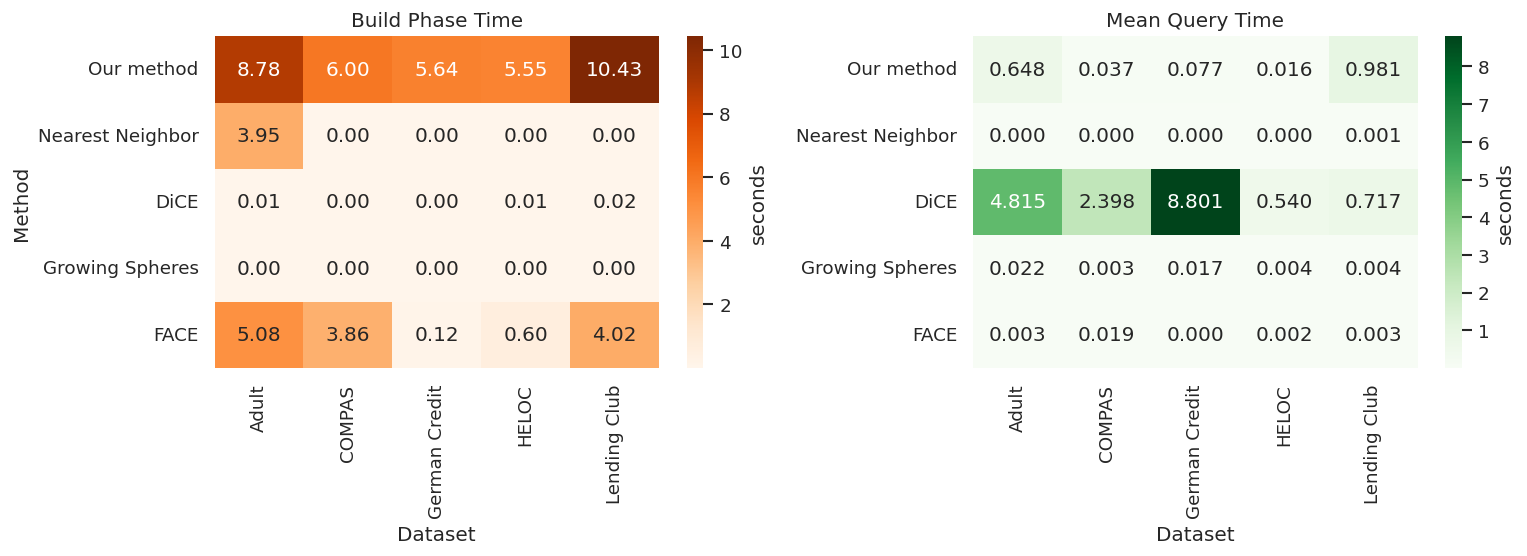

In [76]:
datasets_here = [d for d in dataset_order if d in df["dataset"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.heatmap(
    build_time_table[datasets_here],
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    cbar_kws={"label": "seconds"},
    ax=axes[0],
)
axes[0].set_title("Build Phase Time")
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("Method")

sns.heatmap(
    mean_query_time_table[datasets_here],
    annot=True,
    fmt=".3f",
    cmap="Greens",
    cbar_kws={"label": "seconds"},
    ax=axes[1],
)
axes[1].set_title("Mean Query Time")
axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


In [77]:
runtime_summary = (
    df.groupby(["method_label", "dataset"])
    .agg(
        build_time_s=("build_time_s", "first"),
        total_query_time_s=("runtime_s", "sum"),
        mean_query_time_s=("runtime_s", "mean"),
    )
    .reset_index()
    .groupby("method_label")
    .agg(
        mean_build_time_s=("build_time_s", "mean"),
        std_build_time_s=("build_time_s", "std"),
        mean_total_query_time_s=("total_query_time_s", "mean"),
        std_total_query_time_s=("total_query_time_s", "std"),
        mean_query_time_s=("mean_query_time_s", "mean"),
        std_query_time_s=("mean_query_time_s", "std"),
        n_datasets=("dataset", "size"),
    )
    .reindex(method_order)
)

display(
    runtime_summary.style.format({
        "mean_build_time_s": "{:.3f}",
        "std_build_time_s": "{:.3f}",
        "mean_total_query_time_s": "{:.3f}",
        "std_total_query_time_s": "{:.3f}",
        "mean_query_time_s": "{:.4f}",
        "std_query_time_s": "{:.4f}",
        "n_datasets": "{:d}",
    })
)


,mean_build_time_s,std_build_time_s,mean_total_query_time_s,std_total_query_time_s,mean_query_time_s,std_query_time_s,n_datasets
method_label,,,,,,,
Our method,7.282,2.208,17.580,21.954,0.3516,0.4391,5
Nearest Neighbor,0.791,1.768,0.011,0.013,0.0002,0.0003,5
DiCE,0.008,0.009,172.717,172.372,3.4543,3.4474,5
Growing Spheres,0.001,0.002,0.497,0.444,0.0099,0.0089,5
FACE,2.733,2.226,0.265,0.379,0.0053,0.0076,5


Build and query time should be interpreted together: some methods pay more upfront to build search structures, while others have almost no setup cost but slower or less structured query-time behavior.
